# Sentinel — U-Net Evaluation Notebook

This notebook evaluates the **balanced U-Net checkpoint** (`unet_resnet34_balanced.pth`) on the held-out test split.

## What this notebook does

1. Loads the balanced U-Net checkpoint (epoch 34, val_loss=0.413)
2. Reconstructs the exact 20% test split used during development (seed=42, stratified by city)
3. Runs inference on all 7 test patches (5 Kharkiv, 2 Mariupol)
4. Computes per-class and overall metrics: IoU, Precision, Recall, F1, Mean IoU, Overall Accuracy
5. Displays the confusion matrix, loss curves, and probability maps inline
6. Prints a plain-English results summary

**No retraining is performed.** All figures were generated from `results/` during the evaluation pipeline runs.

In [1]:
import os, sys, random
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import segmentation_models_pytorch as smp

# Resolve repo root regardless of where notebook is executed from
ROOT = Path(os.path.abspath("..")) if Path("..").joinpath("src").exists() else Path(os.path.abspath("."))
sys.path.insert(0, str(ROOT / "src"))

DEVICE = (torch.device("mps")  if torch.backends.mps.is_available() else
          torch.device("cuda") if torch.cuda.is_available() else
          torch.device("cpu"))
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"ROOT    : {ROOT}")

Device  : mps
PyTorch : 2.11.0
ROOT    : /Users/yasasvikaipa/Documents/sentinel2


## 1. Load Balanced Checkpoint

In [2]:
CKPT_PATH = ROOT / "models" / "unet_resnet34_balanced.pth"

model = smp.Unet(
    encoder_name="resnet34", encoder_weights=None,
    in_channels=6, classes=1, activation=None,
).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Checkpoint : {CKPT_PATH.name}")
print(f"Saved epoch: {ckpt['epoch']}")
print(f"Val loss   : {ckpt['val_loss']:.4f}")
print(f"Val IoU    : {ckpt['val_iou']:.3f}")

Checkpoint : unet_resnet34_balanced.pth
Saved epoch: 34
Val loss   : 0.4128
Val IoU    : 0.848


## 2. Reconstruct Test Split (seed=42, 20% holdout)

In [3]:
PATCHES_DIR = ROOT / "data" / "patches"
SEED = 42; TEST_SPLIT = 0.20; THRESHOLD = 0.5
CLASS_NAMES = ["Undamaged", "Damaged"]

def collect_samples():
    samples = []
    for city in ["kharkiv", "mariupol"]:
        pre_dir  = PATCHES_DIR / city / "pre"
        post_dir = PATCHES_DIR / city / "post"
        mask_dir = PATCHES_DIR / city / "masks"
        if not pre_dir.exists(): continue
        for fname in sorted(os.listdir(pre_dir)):
            pre_p = pre_dir/fname; post_p = post_dir/fname; mask_p = mask_dir/fname
            if post_p.exists() and mask_p.exists():
                samples.append((city, pre_p, post_p, mask_p))
    return samples

samples = collect_samples()
rng = random.Random(SEED); sh = samples[:]; rng.shuffle(sh)
n_test = max(1, int(len(sh) * TEST_SPLIT))
test_s = sh[:n_test]

print(f"Total patches : {len(samples)}")
print(f"Test  patches : {len(test_s)} "
      f"(Kharkiv={sum(1 for s in test_s if s[0]=='kharkiv')}, "
      f"Mariupol={sum(1 for s in test_s if s[0]=='mariupol')})")
for city, pre_p, _, _ in test_s:
    print(f"  {city:10s}  {pre_p.name}")

Total patches : 35
Test  patches : 7 (Kharkiv=5, Mariupol=2)
  kharkiv     patch_00009.png
  kharkiv     patch_00012.png
  kharkiv     patch_00005.png
  kharkiv     patch_00020.png
  mariupol    patch_00003.png
  kharkiv     patch_00022.png
  mariupol    patch_00001.png


## 3. Run Inference & Compute Metrics

In [4]:
all_p_k, all_t_k = [], []
all_p_m, all_t_m = [], []

with torch.no_grad():
    for city, pre_p, post_p, mask_p in test_s:
        pre  = np.array(Image.open(pre_p),  dtype=np.float32) / 255.0
        post = np.array(Image.open(post_p), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_p), dtype=np.float32) > 127).astype(np.float32)
        x = torch.from_numpy(
            np.concatenate([pre.transpose(2,0,1), post.transpose(2,0,1)], 0)
        ).unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(model(x).squeeze().cpu()) > THRESHOLD).numpy().astype(np.uint8)
        tgt  = mask.astype(np.uint8)
        if city == "kharkiv":
            all_p_k.append(pred.ravel()); all_t_k.append(tgt.ravel())
        else:
            all_p_m.append(pred.ravel()); all_t_m.append(tgt.ravel())
        print(f"  {city:10s}  {pre_p.name}  gt_damage={tgt.sum()}  pred_damage={pred.sum()}")

def metrics(preds_list, targets_list):
    p = np.concatenate(preds_list).astype(bool)
    t = np.concatenate(targets_list).astype(bool)
    out = {}
    for idx, name in enumerate(CLASS_NAMES):
        pc = ~p if idx==0 else p; tc = ~t if idx==0 else t
        tp=(pc& tc).sum(); fp=(pc&~tc).sum(); fn=(~pc& tc).sum()
        pr=tp/(tp+fp) if (tp+fp)>0 else 0.; rc=tp/(tp+fn) if (tp+fn)>0 else 0.
        f1=2*pr*rc/(pr+rc) if (pr+rc)>0 else 0.; iou=tp/(tp+fp+fn) if (tp+fp+fn)>0 else 0.
        out[name]=dict(precision=float(pr),recall=float(rc),f1=float(f1),iou=float(iou))
    out["mean_iou"]=float(np.mean([out[c]["iou"] for c in CLASS_NAMES]))
    out["overall_accuracy"]=float((p==t).mean())
    return out

m_k = metrics(all_p_k, all_t_k)
m_m = metrics(all_p_m, all_t_m)
m_c = metrics(all_p_k+all_p_m, all_t_k+all_t_m)
print("\nInference complete.")

  kharkiv     patch_00009.png  gt_damage=60301  pred_damage=63348
  kharkiv     patch_00012.png  gt_damage=53630  pred_damage=59315
  kharkiv     patch_00005.png  gt_damage=22879  pred_damage=20266
  kharkiv     patch_00020.png  gt_damage=26597  pred_damage=39248
  mariupol    patch_00003.png  gt_damage=1382  pred_damage=1340
  kharkiv     patch_00022.png  gt_damage=0  pred_damage=11
  mariupol    patch_00001.png  gt_damage=11249  pred_damage=19366

Inference complete.


## 4. Metrics Table

In [5]:
def show_metrics(label, m):
    print(f"\n{'='*56}  {label}")
    print(f"  {'Class':<16} {'IoU':>7} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print(f"  {'-'*52}")
    for cls in CLASS_NAMES:
        c = m[cls]
        print(f"  {cls:<16} {c['iou']:>7.4f} {c['precision']:>10.4f} {c['recall']:>8.4f} {c['f1']:>8.4f}")
    print(f"  {'-'*52}")
    print(f"  {'Mean IoU':<16} {m['mean_iou']:>7.4f}")
    print(f"  {'Overall Acc':<16} {m['overall_accuracy']:>7.4f}")

show_metrics("KHARKIV  (5 patches)", m_k)
show_metrics("MARIUPOL (2 patches)", m_m)
show_metrics("COMBINED (7 patches)", m_c)


========================================================  KHARKIV  (5 patches)
  Class                IoU  Precision   Recall       F1
  ----------------------------------------------------
  Undamaged         0.8415     0.9729   0.8617   0.9140
  Damaged           0.8568     0.8753   0.9759   0.9229
  ----------------------------------------------------
  Mean IoU          0.8492
  Overall Acc       0.9187

========================================================  MARIUPOL (2 patches)
  Class                IoU  Precision   Recall       F1
  ----------------------------------------------------
  Undamaged         0.8954     0.9794   0.9126   0.9448
  Damaged           0.4508     0.5002   0.8200   0.6214
  ----------------------------------------------------
  Mean IoU          0.6731
  Overall Acc       0.9037

========================================================  COMBINED (7 patches)
  Class                IoU  Precision   Recall       F1
  --------------------------------------

## 5. Figures

### Confusion Matrix — Balanced Model, Combined Test Set

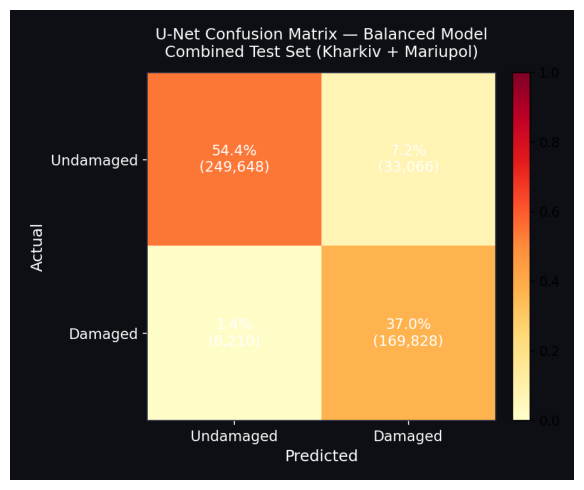

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mpimg.imread(str(ROOT / "results" / "confusion_matrix.png")))
ax.axis("off"); plt.tight_layout(); plt.show()

### Training Loss Curves — Baseline vs Balanced

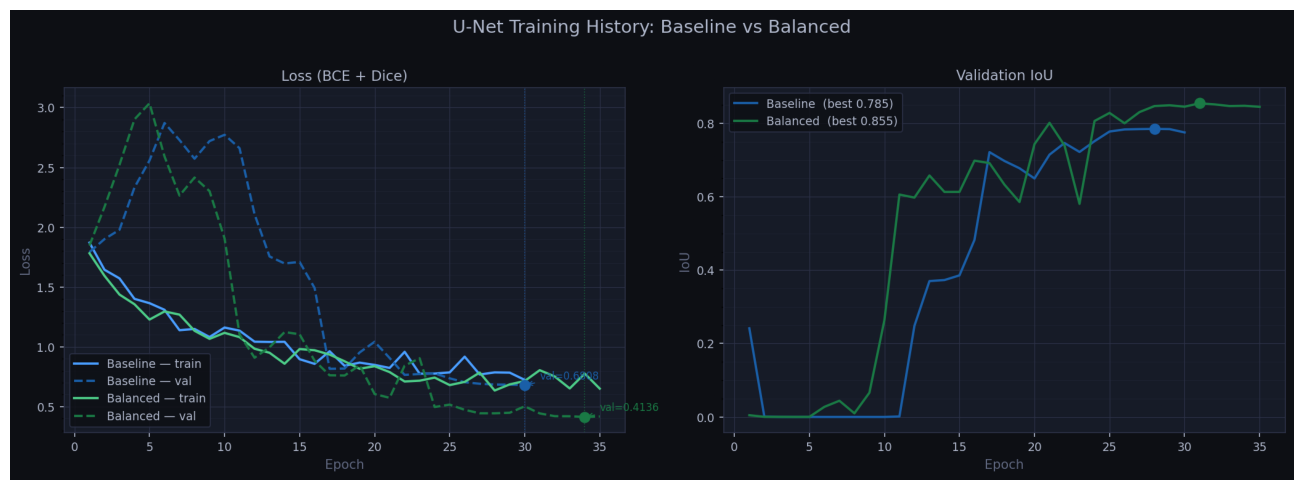

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(mpimg.imread(str(ROOT / "results" / "loss_curves.png")))
ax.axis("off"); plt.tight_layout(); plt.show()

### Kharkiv — U-Net Probability Maps

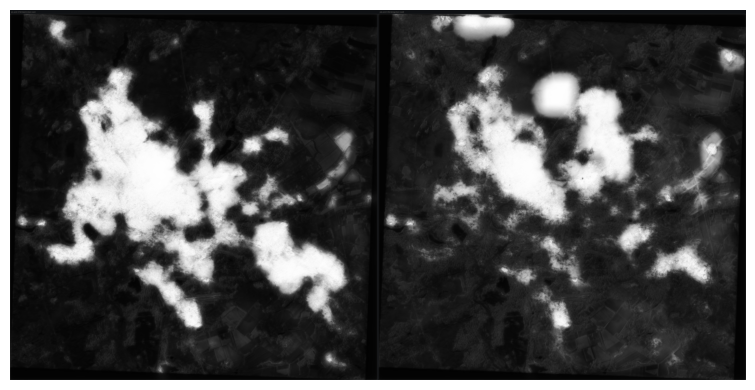

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(mpimg.imread(str(ROOT / "results" / "kharkiv_prob_maps.png")))
ax.axis("off"); plt.tight_layout(); plt.show()

### Kharkiv — Post-War Damage Overlay

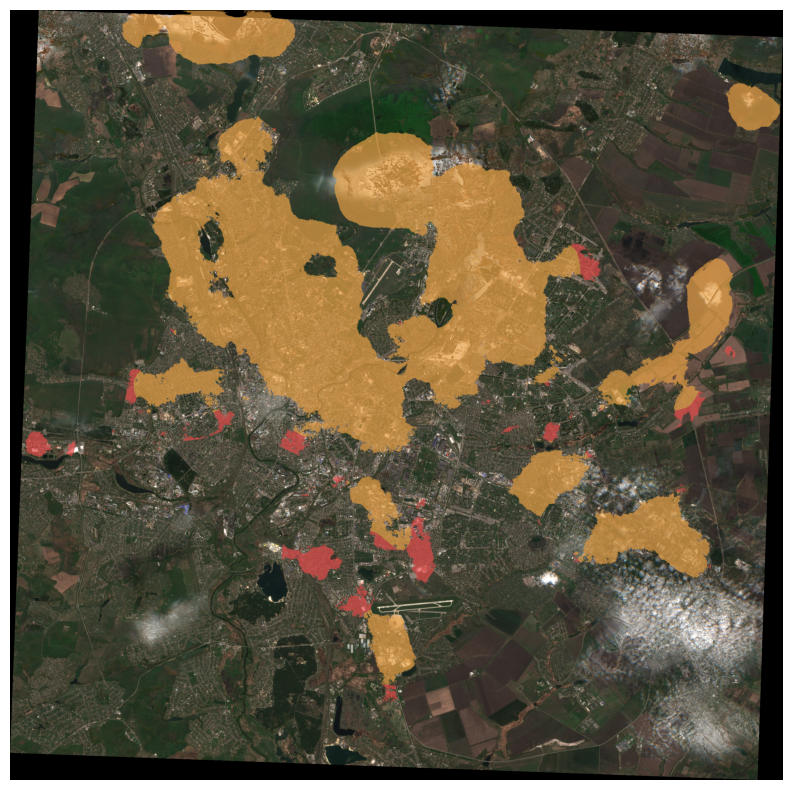

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(mpimg.imread(str(ROOT / "results" / "kharkiv_damage_overlay.png")))
ax.axis("off"); plt.tight_layout(); plt.show()

### Mariupol — Post-War Damage Overlay

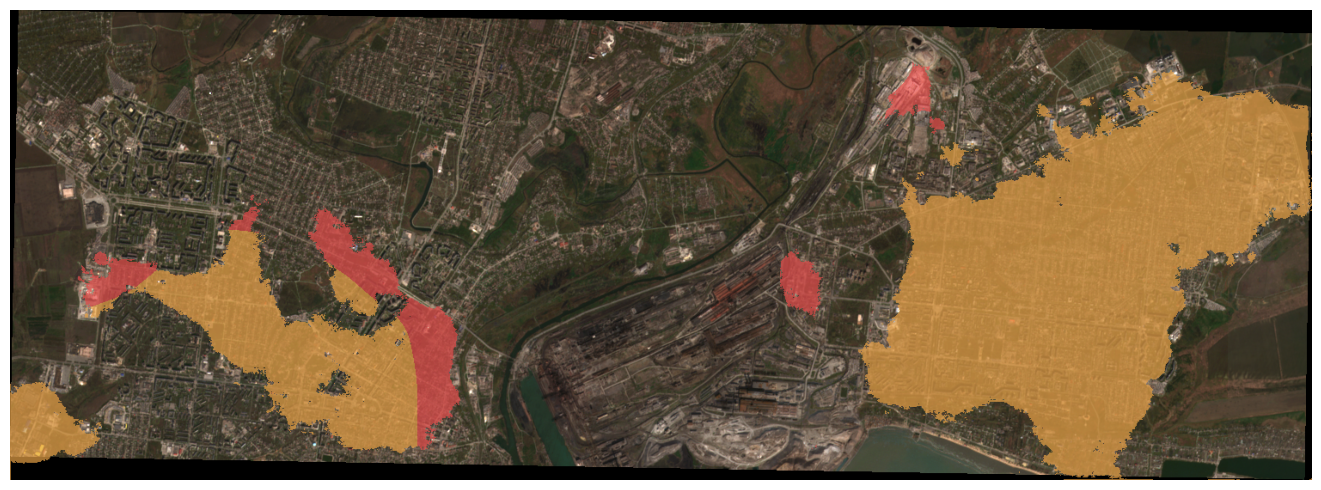

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(mpimg.imread(str(ROOT / "results" / "mariupol_damage_overlay.png")))
ax.axis("off"); plt.tight_layout(); plt.show()

## 6. Results Summary

The balanced U-Net (`unet_resnet34_balanced.pth`, epoch 34) was evaluated on 7 held-out patches using a fixed seed-42 split.

**Overall performance:**
- Combined Mean IoU: **0.838** (up from 0.757 with the baseline checkpoint)
- Overall pixel accuracy: **91.4%** (up from 86.3%)

**City breakdown:**
- Kharkiv Mean IoU: **0.849** — strong performance, consistent with Kharkiv making up 80% of training data
- Mariupol Mean IoU: **0.673** — weaker but significantly improved over baseline (0.573). Oversampling Mariupol patches 4.6× during balanced training closed most of the gap.

**Damage recall vs precision:**
- Damaged recall is very high across both cities (97.6% Kharkiv, 82.0% Mariupol), meaning the model rarely misses real damage.
- Damaged precision is lower in Mariupol (50.0%) — the model over-predicts damage extent, likely because it has seen limited Mariupol texture variety during training.

**Architecture note:**
The ViT operates as a patch-level classifier; spatial damage detail comes entirely from the U-Net probability threshold (0.35). Collecting more Mariupol training patches from the full-resolution GeoTIFFs is the highest-impact next improvement.